In [ ]:
#install dependencies
%pip install -q scikit-learn matplotlib torch torchvision torchaudio torchcodec librosa dagshub datasets ffmpeg


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Libraries
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import numpy as np
import librosa
from librosa.display import specshow
from datasets import load_dataset, Audio as HfAudio, load_dataset_builder
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchaudio.transforms import FrequencyMasking, TimeMasking, Resample, Spectrogram, MFCC, MelSpectrogram, PitchShift, Speed
import warnings
import random
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import keras
from keras import Sequential
from keras.layers import Embedding, Dense, LSTM, Bidirectional
from keras.losses import BinaryCrossentropy, CategoricalFocalCrossentropy
from keras.models import Sequential
from keras.optimizers import Adam
from keras.preprocessing.sequence import pad_sequences
from keras.metrics import AUC, Precision, Recall, BinaryAccuracy
from collections import defaultdict


warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


dataset = None
try:
    dataset_builder = load_dataset_builder("ashraq/esc50")
    print(dataset_builder.info.features)
    dataset = load_dataset("ashraq/esc50")
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"Dataset {dataset} load failed: {e}")
    raise

c:\Users\isaac\Downloads\Projects\LocalInference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


{'filename': Value('string'), 'fold': Value('int64'), 'target': Value('int64'), 'category': Value('string'), 'esc10': Value('bool'), 'src_file': Value('int64'), 'take': Value('string'), 'audio': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None)}
Dataset loaded successfully.


In [3]:
def export_split_audio(split_ds, split_name):
    split_dir = data_dir / split_name
    split_dir.mkdir(parents=True, exist_ok=True)
    for example in split_ds:
        audio = example["audio"]
        filename = example["filename"]
        output_path = split_dir / filename
        if not output_path.exists():
            with open(output_path, "wb") as file_handle:
                file_handle.write(audio["bytes"])
    return split_dir


def preprocess_audio(audio_path, target_sr=16000, segment_sec=1.0, hop_sec=0.5):
    '''Converts audio from stereo to mono to reduce file size'''
    mono_audio, sr = librosa.load(audio_path, sr=target_sr, mono=True)
    '''cleaning audio data by applying amplitude normalization (ensures consistent loudness)'''
    peak = np.abs(mono_audio).max()
    if peak > 0:
        mono_audio = mono_audio / peak * 0.99
    '''Trimming audio by removing silence from beginning and end of audio sample, ensures audio doesn't learn from empty data'''
    trim_audio, _ = librosa.effects.trim(mono_audio, top_db=20)
    '''Chunks audio files into smaller segments to manage memory restrictions and improving processing efficiency'''
    seg_len = int(segment_sec * sr)
    hop_len = int(hop_sec * sr)

    if len(trim_audio) < seg_len:
        trim_audio = np.pad(trim_audio, (0, seg_len - len(trim_audio)))

    framed = librosa.util.frame(trim_audio, frame_length=seg_len, hop_length=hop_len)
    segments = framed.T.astype(np.float32)

    return segments, sr


def preprocess_split_audio(split_dir):
    processed_samples = []
    for audio_path in sorted(split_dir.glob("*.wav")):
        segments, sr = preprocess_audio(audio_path)
        processed_samples.append(
            {
                "file": audio_path.name,
                "segments": segments,
                "sample_rate": sr,
            }
        )
    return processed_samples


data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

ds = dataset["train"].cast_column("audio", HfAudio(decode=False))


    
labels_set = list(dict.fromkeys(ds["category"]))
print(labels_set)

dictionary = defaultdict(int)
positive_categories = {cat: idx for idx, cat in enumerate(labels_set)}
print(dict(dictionary))

labels = np.array([positive_categories.get(label, 0)for label in ds["category"]], dtype=np.int64)



indices = np.arange(len(ds))

train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED,
)

val_idx, test_idx, val_labels, test_labels = train_test_split(
    temp_idx,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED,
)

train_ds = ds.select(train_idx.tolist())
val_ds = ds.select(val_idx.tolist())
test_ds = ds.select(test_idx.tolist())

print(len(train_ds))
print(len(test_ds))

train_audio_dir = export_split_audio(train_ds, "train")
val_audio_dir = export_split_audio(val_ds, "val")
test_audio_dir = export_split_audio(test_ds, "test")

train_processed = preprocess_split_audio(train_audio_dir)
val_processed = preprocess_split_audio(val_audio_dir)
test_processed = preprocess_split_audio(test_audio_dir)

print(f"Saved train audio to {train_audio_dir}")
print(f"Saved val audio to {val_audio_dir}")
print(f"Saved test audio to {test_audio_dir}")
print(f"Train preprocessed files: {len(train_processed)}")
print(f"Val preprocessed files: {len(val_processed)}")
print(f"Test preprocessed files: {len(test_processed)}")
print(f"Positive train labels: {train_labels.mean():.3f}")
print(f"Positive val labels: {val_labels.mean():.3f}")
print(f"Positive test labels: {test_labels.mean():.3f}")

['dog', 'chirping_birds', 'vacuum_cleaner', 'thunderstorm', 'door_wood_knock', 'can_opening', 'crow', 'clapping', 'fireworks', 'chainsaw', 'airplane', 'mouse_click', 'pouring_water', 'train', 'sheep', 'water_drops', 'church_bells', 'clock_alarm', 'keyboard_typing', 'wind', 'footsteps', 'frog', 'cow', 'brushing_teeth', 'car_horn', 'crackling_fire', 'helicopter', 'drinking_sipping', 'rain', 'insects', 'laughing', 'hen', 'engine', 'breathing', 'crying_baby', 'hand_saw', 'coughing', 'glass_breaking', 'snoring', 'toilet_flush', 'pig', 'washing_machine', 'clock_tick', 'sneezing', 'rooster', 'sea_waves', 'siren', 'cat', 'door_wood_creaks', 'crickets']
{}
1400
300
Saved train audio to data\train
Saved val audio to data\val
Saved test audio to data\test
Train preprocessed files: 1999
Val preprocessed files: 1349
Test preprocessed files: 1330
Positive train labels: 24.500
Positive val labels: 24.500
Positive test labels: 24.500


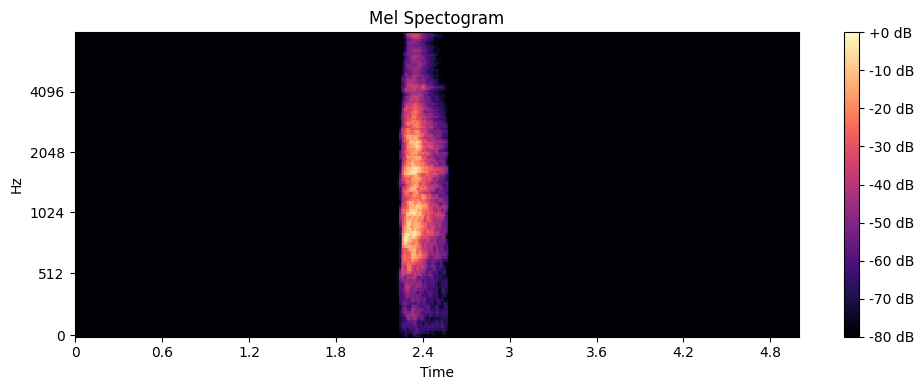

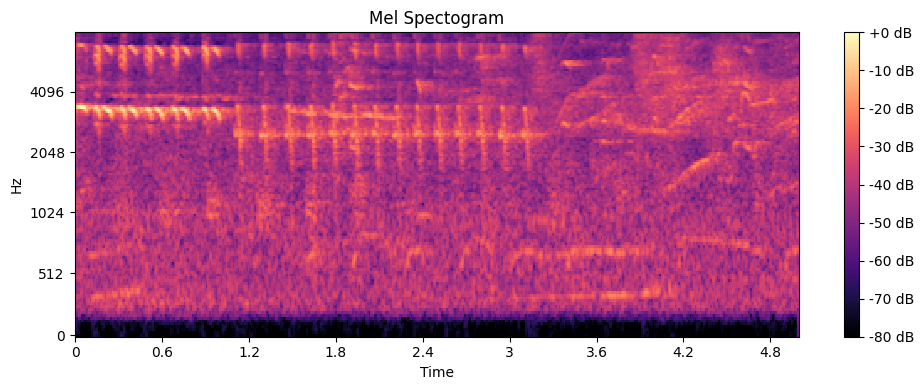

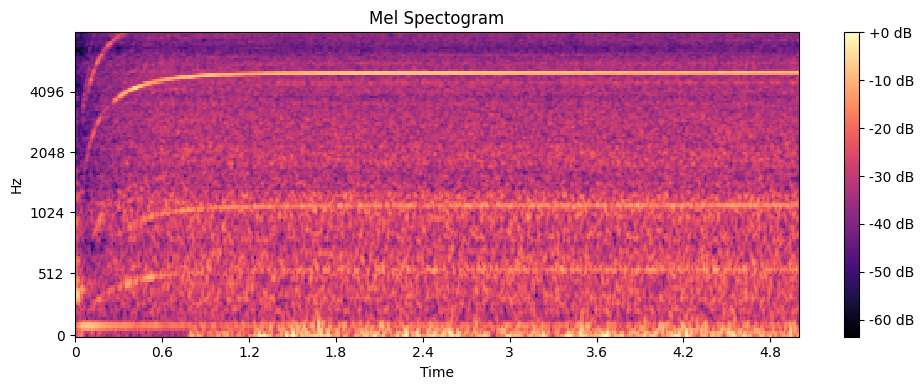

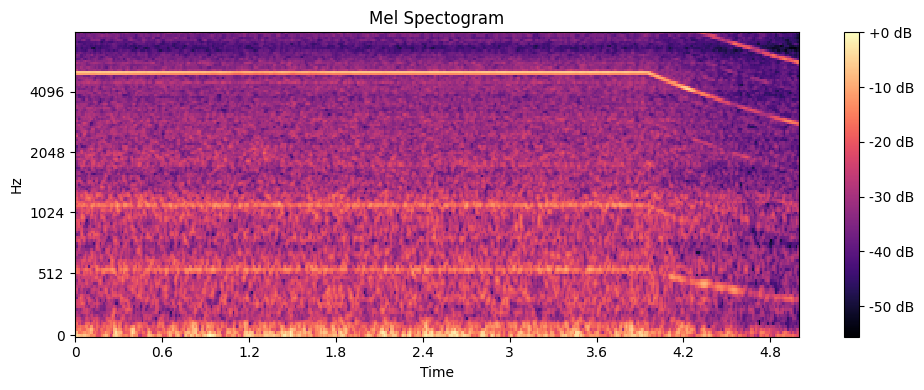

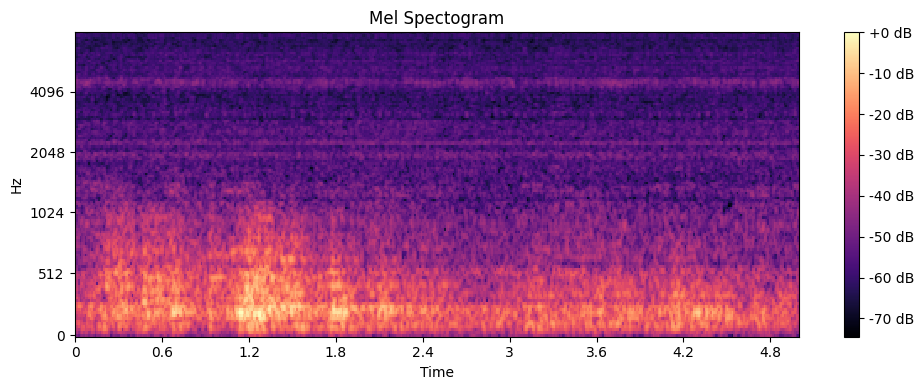

In [ ]:
#Visualize audio files as mel_frq cepstrum coefficient
def plot_MFCC(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    spectrogram = librosa.feature.MFCC(y=y, sr=sr, n_mels=128, fmax=8000)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(10, 4))
    specshow(spectrogram_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000)
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel-Frequency Cepstral Coefficients")
    plt.tight_layout()
    plt.show()

#as mel spectogram
def plot_MFCC(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(10, 4))
    specshow(spectrogram_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000)
    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Spectogram")
    plt.tight_layout()
    plt.show()

for audio_file in list((Path("data/train")).glob("*.wav"))[:5]:
    plot_MFCC(audio_file)

Train samples: 9705
Val samples: 2088
Test samples: 2117
Example tensor shape: torch.Size([1, 40, 64])
 Batch Size: 64, Epochs: 200, Learning Rate: 0.001
Epoch 01/200 | Train Loss: 3.2522 | Train Acc: 0.0922 | Val Loss: 3.0347 | Val Macro F1: 0.0864 | Val Macro Recall: 0.1274 | Val Macro Precision: 0.1109
Epoch 02/200 | Train Loss: 2.7242 | Train Acc: 0.1766 | Val Loss: 2.7666 | Val Macro F1: 0.1784 | Val Macro Recall: 0.2265 | Val Macro Precision: 0.2363
Epoch 03/200 | Train Loss: 2.5443 | Train Acc: 0.2364 | Val Loss: 2.4798 | Val Macro F1: 0.2609 | Val Macro Recall: 0.2869 | Val Macro Precision: 0.3447
Epoch 04/200 | Train Loss: 2.3808 | Train Acc: 0.2771 | Val Loss: 2.3217 | Val Macro F1: 0.2967 | Val Macro Recall: 0.3271 | Val Macro Precision: 0.3775
Epoch 05/200 | Train Loss: 2.3145 | Train Acc: 0.2887 | Val Loss: 2.3169 | Val Macro F1: 0.2872 | Val Macro Recall: 0.3204 | Val Macro Precision: 0.3848
Epoch 06/200 | Train Loss: 2.1743 | Train Acc: 0.3308 | Val Loss: 2.2473 | Val Ma

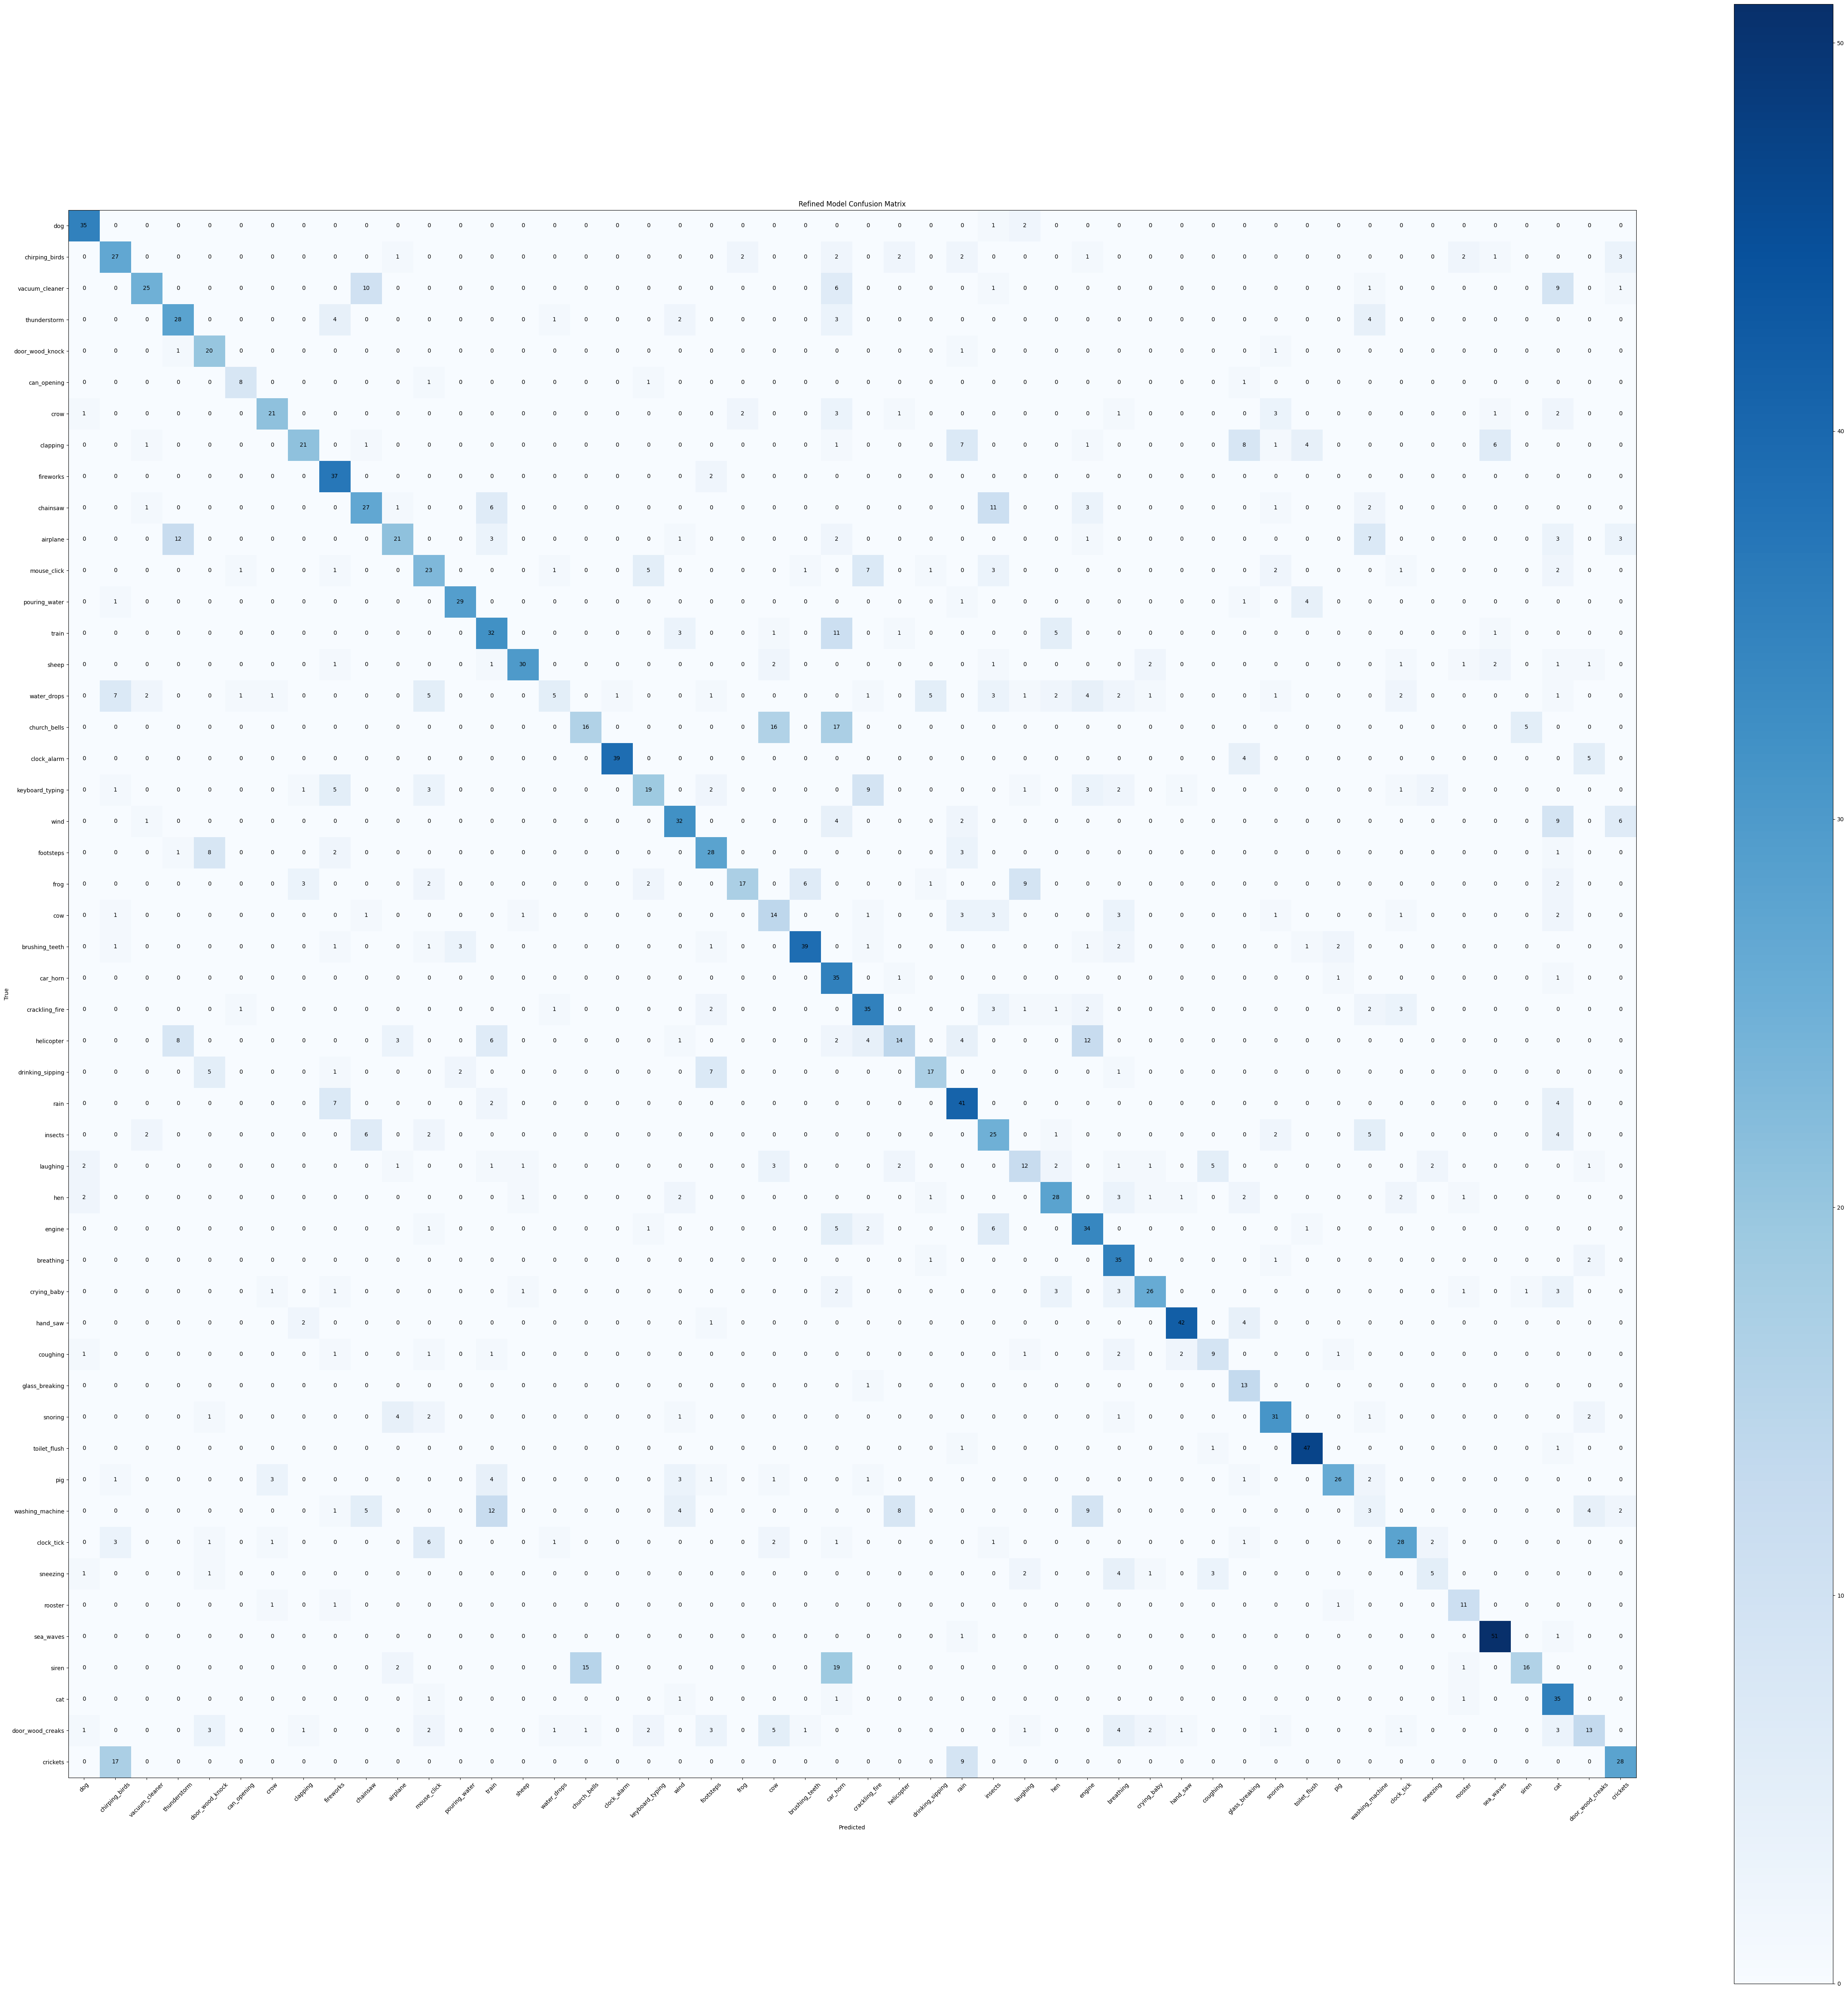


Classification Report:
                  precision    recall  f1-score   support

             dog       0.81      0.92      0.86        38
  chirping_birds       0.46      0.63      0.53        43
  vacuum_cleaner       0.78      0.47      0.59        53
    thunderstorm       0.56      0.67      0.61        42
 door_wood_knock       0.51      0.87      0.65        23
     can_opening       0.73      0.73      0.73        11
            crow       0.75      0.60      0.67        35
        clapping       0.75      0.41      0.53        51
       fireworks       0.59      0.95      0.73        39
        chainsaw       0.54      0.52      0.53        52
        airplane       0.64      0.40      0.49        53
     mouse_click       0.46      0.48      0.47        48
   pouring_water       0.85      0.81      0.83        36
           train       0.47      0.59      0.52        54
           sheep       0.88      0.70      0.78        43
     water_drops       0.50      0.11      0.18

In [11]:
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
)


class AudioDataset(Dataset):
    def __init__(
        self,
        processed_samples,
        label_lookup,
        n_fft=1024,
        n_mels=64,
        target_size=(40, 64),
        use_augment=False,
    ):
        self.items = []
        self.target_size = target_size
        self.use_augment = use_augment

        #Flattens file-level segments for batching
        for sample in processed_samples:
            filename = sample["file"]
            label = label_lookup.get(filename)
            if label is None:
                continue
            for segment in sample["segments"]:
                self.items.append((segment.astype(np.float32), int(label)))

        self.mfcc = MFCC(
            n_mfcc=40,
            sample_rate=16000,
            melkwargs={"n_fft": n_fft, "hop_length": 160, "n_mels": n_mels, "center": False},
        )
        self.spec_aug = torch.nn.Sequential(
            FrequencyMasking(freq_mask_param=40),
            TimeMasking(time_mask_param=40)
        )
        #pitch shift between 2 semitones down and 3 semitones up
        self.pitch_shifts = [PitchShift(sample_rate=16000, n_steps=s) for s in range(-2, 3) if s != 0]
        #adjust different speeds
        self.speed_transforms = [Speed(orig_freq=16000, factor=f) for f in [0.9, 0.95, 1.05, 1.1]]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        segment, label = self.items[index]

        waveform = torch.tensor(segment, dtype=torch.float32).unsqueeze(0)
        peak = waveform.abs().amax().clamp_min(1e-8)
        waveform = (waveform / peak) * 0.99


        features = self.mfcc(waveform)
        if self.use_augment:
            features = self.spec_aug(features)

        features = F.interpolate(
            features.unsqueeze(0),
            size=self.target_size,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)

        return features, torch.tensor(label, dtype=torch.long)



# CNN + Bidirectional LSTM for MFCC feature-map classification
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=len(positive_categories), lstm_hidden=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.lstm = nn.LSTM(
            input_size=128 * 8,
            hidden_size=lstm_hidden,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.permute(0, 3, 1, 2).contiguous().flatten(2)
        _, (hn, _) = self.lstm(x)

        last_forward = hn[-2]
        last_backward = hn[-1]
        h = torch.cat([last_forward, last_backward], dim=1)
        return self.classifier(h)


class EarlyStopper:
    def __init__(self, patience=15, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        if mode == "min":
            self.best_value = float("inf")
        else:
            self.best_value = -float("inf")

    def step(self, value):
        if self.mode == "min":
            improved = value < (self.best_value - self.min_delta)
        else:
            improved = value > (self.best_value + self.min_delta)

        if improved:
            self.best_value = value
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


#Preprocessing Pipeline: Converts the raw audio waveform into an MFCC spectogram
class Pipeline(torch.nn.Module):
    def __init__(
        self,
        input_freq=16000,
        resample_freq=8000,
        n_fft=1024,
        n_mel=256,
    ):
        super().__init__()
        self.resample = Resample(orig_freq = input_freq, new_freq = resample_freq)
        self.spec = Spectrogram(n_fft=n_fft, power = 2)
        
        '''Data augmentation;
        - Frequency Masking: Applies masking over spectogram in frequency domain
        - Time Masking: Applies masking over spectogram in time domain
        '''
        self.spec_aug = torch.nn.Sequential(
            FrequencyMasking(freq_mask_param=80),
            TimeMasking(time_mask_param=80),
        )

        self.mfcc = MFCC(
            n_mfcc=13,
            sample_rate=16000,
            melkwargs={"n_fft": n_fft, "hop_length": 160, "n_mels": n_mel, "center": False},
        )


    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        '''Resamples the input'''
        resampled = self.resample(waveform)
        peak = resampled.abs().amax(dim=-1, keepdim=True).clamp_min(1e-8)
        resampled = (resampled / peak) * 0.99

        '''Audio to POWER spectogram (shows the raw distribution of signal energy)'''
        spec = self.spec(resampled)

        '''Data augmentation'''
        spec = self.spec_aug(spec)

        '''Converts to mel-scale for appropriate evaluation'''
        mel = self.mfcc(spec)

        return mel


#For multiclass classification, every class should have a stable numeric label.
def build_label_lookup(split_ds):
    return {
        row["filename"]: positive_categories.get(row["category"], 0)
        for row in split_ds
    }


def get_num_classes(dataset):
    labels_arr = np.array([label for _, label in dataset.items], dtype=np.int64)
    return int(labels_arr.max()) + 1 if labels_arr.size else 0


def get_dataset_label_counts(dataset):
    labels_arr = np.array([label for _, label in dataset.items], dtype=np.int64)
    unique_labels, counts = np.unique(labels_arr, return_counts=True)
    return dict(zip(unique_labels.tolist(), counts.tolist()))

#Constructs weights per class for CrossEntropyLoss, where classes with fewer data get larger weights to not penalize model
def compute_class_weights_for_ce(dataset):
    label_counts = get_dataset_label_counts(dataset)
    num_classes = get_num_classes(dataset)
    if num_classes == 0:
        return torch.tensor([], dtype=torch.float32)

    total = sum(label_counts.values())
    weights = np.ones(num_classes, dtype=np.float32)
    for label, count in label_counts.items():
        weights[label] = total / (num_classes * max(count, 1))
    return torch.tensor(weights, dtype=torch.float32)

#Samples from rarer classes are given a higher sampling probability, so it appears more often during training and thus making model more balanced
def make_weighted_sampler(dataset):
    label_counts = get_dataset_label_counts(dataset)
    if not label_counts:
        return WeightedRandomSampler(weights=torch.tensor([], dtype=torch.double), num_samples=0, replacement=True)

    sample_weights = [1.0 / max(label_counts[label], 1) for _, label in dataset.items]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

#Evaluates loss and predictions for model
def evaluate_multiclass(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * xb.size(0)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

            y_true.extend(yb.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / max(total, 1)
    accuracy = correct / max(total, 1)
    return avg_loss, accuracy, y_true, y_pred, y_prob


def run_model(
    tuning=False,
    early_stopping=False,
    use_class_weights=False,
    use_weighted_sampler=False
):
    if tuning:
        lr_list = [0.001, 0.0001, 0.00001]
        epochs_list = [12, 20, 50, 100]
        batch_list = [16, 32, 64]
    else:
        lr_list = [0.001]
        epochs_list = [200]
        batch_list = [64]

    complete_histories = []
    best_score = -float("inf")
    best_history_df = None
    best_params = {}
    best_test_loader = None

    for learning_rate in lr_list:
        for epoch in epochs_list:
            for batch_size in batch_list:
                print(f" Batch Size: {batch_size}, Epochs: {epoch}, Learning Rate: {learning_rate}")

                sampler = make_weighted_sampler(train_dataset) if use_weighted_sampler else None
                train_loader = DataLoader(
                    train_dataset,
                    batch_size=batch_size,
                    shuffle=(sampler is None),
                    sampler=sampler,
                    num_workers=0,
                )
                val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
                test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

                current_model = CNNLSTM(num_classes=get_num_classes(train_dataset)).to(device)
                current_optimizer = torch.optim.Adam(current_model.parameters(), lr=learning_rate)

                if use_class_weights:
                    class_weights = compute_class_weights_for_ce(train_dataset).to(device)
                    current_criterion = nn.CrossEntropyLoss(weight=class_weights)
                else:
                    current_criterion = nn.CrossEntropyLoss()

                history = []

                if early_stopping:
                    early_stopper = EarlyStopper(patience=7, min_delta=0.001, mode="min")
                    best_val_loss = -float("inf")
                    best_model_run = None
                else:
                    best_model_run = None

                for e in range(1, epoch + 1):
                    current_model.train()

                    running_loss = 0.0
                    running_correct = 0
                    running_total = 0

                    for xb, yb in train_loader:
                        xb, yb = xb.to(device), yb.to(device)

                        current_optimizer.zero_grad()
                        outputs = current_model(xb)
                        loss = current_criterion(outputs, yb)
                        loss.backward()
                        current_optimizer.step()

                        running_loss += loss.item() * xb.size(0)
                        preds = outputs.argmax(dim=1)
                        running_correct += (preds == yb).sum().item()
                        running_total += xb.size(0)

                    train_loss = running_loss / max(running_total, 1)
                    train_acc = running_correct / max(running_total, 1)

                    val_loss, val_acc_default, val_true, val_pred, val_prob = evaluate_multiclass(
                        current_model,
                        val_loader,
                        current_criterion,
                    )

                    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
                        np.array(val_true),
                        np.array(val_pred),
                        average="weighted",
                        zero_division=0,
                    )
            
                    history.append(
                        {
                            "epoch": e,
                            "train_loss": train_loss,
                            "train_acc": train_acc,
                            "val_loss": val_loss,
                            "val_acc": val_acc_default,
                            "val_precision_macro": val_precision,
                            "val_recall_macro": val_recall,
                            "val_f1_macro": val_f1,
                            
                        }
                    )

                    if early_stopping:
                        if val_loss < best_val_loss:
                            best_val_loss = val_loss
                            best_model_run = current_model.state_dict()

                        if early_stopper.step(val_loss):
                            print(f"Early stopping at epoch {e}")
                            break

                    print(
                        f"Epoch {e:02d}/{epoch} | "
                        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                        f"Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1:.4f} | "
                        f"Val Macro Recall: {val_recall:.4f} | Val Macro Precision: {val_precision:.4f}"
                    )

                history_df = pd.DataFrame(history)
                final_score = history_df["val_f1_macro"].max()

                complete_histories.append(
                    {
                        "Epochs": epoch,
                        "Learning Rate": learning_rate,
                        "History": history_df,
                        "final_val_f1_macro": final_score,
                    }
                )

                if final_score > best_score:
                    best_score = final_score
                    best_history_df = history_df
                    best_test_loader = test_loader
                    best_params = {
                        "Epochs": epoch,
                        "Learning Rate": learning_rate,
                        "batch_size": batch_size,
                        "Model state": best_model_run if (early_stopping and best_model_run is not None) else current_model.state_dict(),
                    }

    return best_history_df, best_params, best_test_loader, train_dataset


train_label_lookup = build_label_lookup(train_ds)
val_label_lookup = build_label_lookup(val_ds)
test_label_lookup = build_label_lookup(test_ds)

train_dataset = AudioDataset(train_processed, train_label_lookup, use_augment=True)
val_dataset = AudioDataset(val_processed, val_label_lookup, use_augment=False)
test_dataset = AudioDataset(test_processed, test_label_lookup, use_augment=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Example tensor shape: {train_dataset[0][0].shape}")

refined_history_df, params, test_loader, train_dataset = run_model(
    tuning=False,
    early_stopping=True,
    use_class_weights=True,
    use_weighted_sampler=True,
)
print(f"Refined Model DataFrame:\n{refined_history_df.tail(3)}")
print(f"Params {params}")

#Obtaining best model for evaluation
best_model_state = params["Model state"]
best_model_final = CNNLSTM(num_classes=get_num_classes(train_dataset)).to(device)
best_model_final.load_state_dict(best_model_state)
best_model_final.eval()

class_weights_eval = compute_class_weights_for_ce(train_dataset).to(device)
best_criterion = nn.CrossEntropyLoss(weight=class_weights_eval)


test_loss, test_acc_default, y_true, y_pred, y_prob = evaluate_multiclass(best_model_final, test_loader, best_criterion)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    np.array(y_true),
    np.array(y_pred),
    average="macro",
    zero_division=0,
)
test_balanced_acc = balanced_accuracy_score(np.array(y_true), np.array(y_pred))

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy (argmax): {test_acc_default:.4f}")
print(f"Test Precision (macro): {test_precision:.4f}")
print(f"Test Recall (macro): {test_recall:.4f}")
print(f"Test F1 (macro): {test_f1:.4f}")
print(f"Test Balanced Accuracy: {test_balanced_acc:.4f}")

num_classes = get_num_classes(train_dataset)
class_ids = list(range(num_classes))
class_names = list(positive_categories.keys())

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=class_ids)

plt.figure(figsize=(len(class_ids), max(len(class_ids) - 1, 4)))
plt.imshow(cm, cmap="Blues")
plt.title("Refined Model Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_ids)), class_names, rotation=45)
plt.yticks(range(len(class_ids)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=class_ids, target_names=class_names, zero_division=0))



In [12]:
torch.save(best_model_final.state_dict(), 'path.pth')